In [28]:
# import all libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import math
import random

In [29]:
# load csv
b_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')

C:\Users\Golbe\AppData\Local\Temp\ipykernel_29588\1278216079.py:2: DtypeWarning: Columns (18,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  b_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')


In [30]:
base_df = b_df.copy()

In [31]:
base_df['year'] = base_df['tourney_id'].str.split('-').str[0].astype(int)

In [32]:
player_id_year_comb = base_df[['player_id','year','player_age']].drop_duplicates().sort_values(by='player_id',ascending=True)

In [33]:
check_if_exitst_list = []
new_player_list = []
under_26_list = []
for player_id_x, player_age in zip(player_id_year_comb['player_id'].to_list(),player_id_year_comb['player_age'].to_list()):
    if player_id_x not in check_if_exitst_list:
        check_if_exitst_list.append(player_id_x)
        new_player_list.append(True)
        if player_age <= 25:
            under_26_list.append(True)
        else:
            under_26_list.append(False)
    else:
        new_player_list.append(False)
        under_26_list.append(False)

In [34]:
isnewplayer = pd.DataFrame(zip(new_player_list,under_26_list),columns=['is_it_new_player','is_also_under_26'])

In [35]:
complete_df = pd.concat(
    [
        player_id_year_comb.reset_index(drop=True),
        isnewplayer.reset_index(drop=True)
    ],
    axis=1
)


In [36]:
complete_df.shape

(103412, 5)

In [37]:
complete_df

,player_id,year,player_age,is_it_new_player,is_also_under_26
0,100001,1969,55.0,True,False
1,100001,1970,56.0,False,False
2,100003,1971,44.0,True,False
3,100004,1968,40.0,True,False
4,100005,1972,44.0,True,False
...,...,...,...,...,...
103407,213496,2024,20.0,True,True
103408,213523,2024,23.0,True,True
103409,213608,2024,16.0,True,True
103410,213626,2024,16.0,True,True


In [38]:
result = (
    complete_df
        .groupby('year')
        .agg(
            number_new_players=('is_it_new_player', 'sum'),
            number_under_26=('is_also_under_26', 'sum')
        )
        .reset_index()
)
result.head(3)

,year,number_new_players,number_under_26
0,1968,148,89
1,1969,61,30
2,1970,54,28


In [39]:
count_unique_players = base_df[['year','player_age','player_id']].copy()
count_unique_players = count_unique_players.drop_duplicates()
count = (
    count_unique_players
        .groupby('year')
        .agg(
            number_players=('player_id', 'count'),
            average_age=('player_age', 'mean')
        )
        .reset_index()
)
count['average_age'] = count['average_age'].round()
count.head(3)

,year,number_players,average_age
0,1968,256,25.0
1,1969,158,26.0
2,1970,156,26.0


In [40]:
only_2000_or_more = result[result['year'] >= 2000]
count_2000_or_more = count[count['year'] >= 2000]

[]

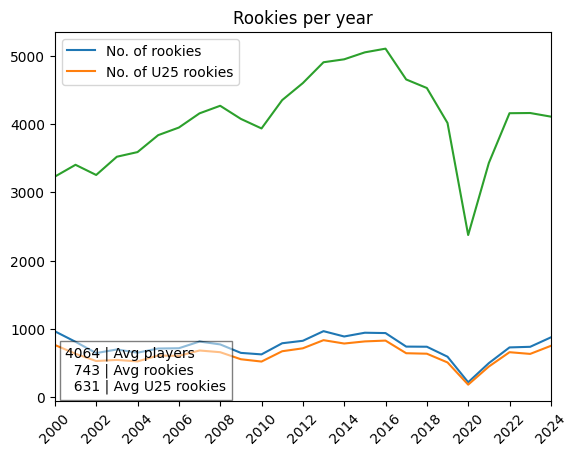

In [41]:
plt.plot(only_2000_or_more['year'],only_2000_or_more['number_new_players'],label='No. of rookies')
plt.plot(only_2000_or_more['year'],only_2000_or_more['number_under_26'], label='No. of U25 rookies')
plt.title('Rookies per year')
plt.plot(count_2000_or_more['year'],count_2000_or_more['number_players'])
plt.legend()
plt.xlim(left=2000,right=2024)
plt.xticks(range(2000,2025,2),rotation=45)
#plt.yscale('log')
tot_player = count_2000_or_more['number_players'].mean()
avg_new = only_2000_or_more['number_new_players'].mean()
avg_u25 = only_2000_or_more['number_under_26'].mean()
plt.text(2000.5, 100,
         f'{tot_player:.0f} | Avg players\n  {avg_new:.0f} | Avg rookies\n  {avg_u25:.0f} | Avg U25 rookies',
         fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.plot()

In [42]:
print(only_2000_or_more['number_new_players'].mean())
print(only_2000_or_more['number_new_players'].median())
print(only_2000_or_more['number_under_26'].mean())
print(only_2000_or_more['number_under_26'].median())

743.24
740.0
631.48
638.0


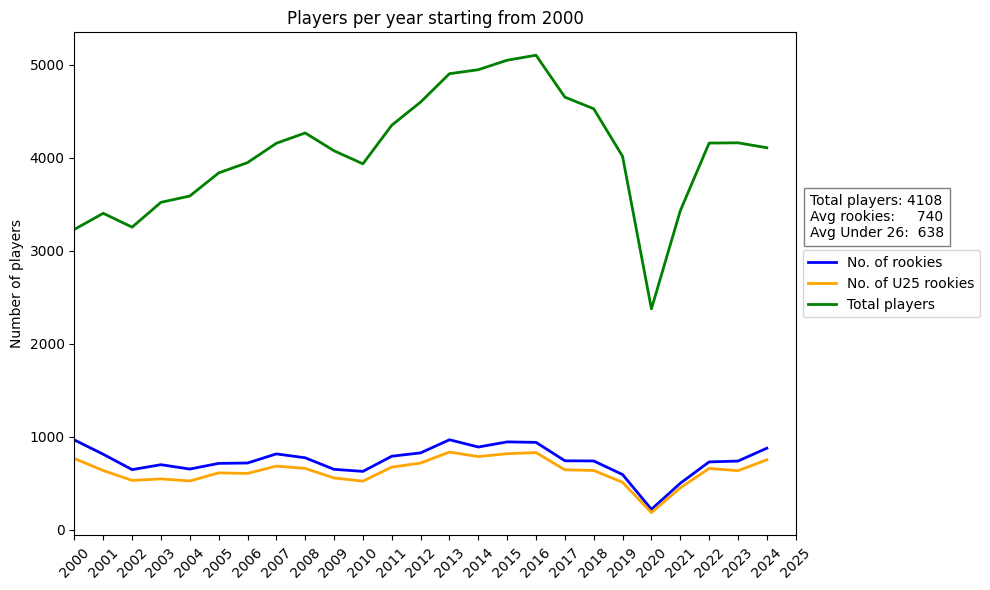

In [43]:
fig, ax = plt.subplots(figsize=(10,6))

# --- Your lines ---
ax.plot(only_2000_or_more['year'], only_2000_or_more['number_new_players'],
        label='No. of rookies', color='blue', linewidth=2)
ax.plot(only_2000_or_more['year'], only_2000_or_more['number_under_26'],
        label='No. of U25 rookies', color='orange', linewidth=2)
ax.plot(count_2000_or_more['year'], count_2000_or_more['number_players'],
        label='Total players', color='green', linewidth=2, linestyle='-')

# --- Titles and axes ---
ax.set_title('Players per year starting from 2000')
ax.set_xlim(2000, 2024)
ax.set_xticks(range(2000, 2026, 1))
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Number of players')

# --- Legend outside ---
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# --- Text box outside ---
tot_player = count_2000_or_more['number_players'].median()
avg_new = only_2000_or_more['number_new_players'].median()
avg_u25 = only_2000_or_more['number_under_26'].median()

fig.text(0.815, 0.63,  # x, y in figure coordinates (0-1)
         f'Total players: {tot_player:.0f}\nAvg rookies:     {avg_new:.0f}\nAvg Under 26:  {avg_u25:.0f}',
         fontsize=10, va='center', ha='left',
         bbox=dict(facecolor='white', alpha=0.5))
plt.tight_layout()
plt.show()


In [51]:
full_df = b_df.copy()
full_df_2 = b_df.copy()

In [57]:
b_df.shape

(1282807, 132)

In [53]:
# fill missing elo with baseline as that is where everything starts
print(full_df['player_rank'].isna().sum())
full_df['player_rank'] = full_df['player_rank'].replace(np.nan,2268)
print(full_df['player_rank'].isna().sum())

# also make one without nan values to compare
print(base_df['player_rank'].isna().sum())
full_df_2['player_rank'] = full_df_2['player_rank'].replace(2268,np.nan)
print(full_df_2['player_rank'].isna().sum())
full_df_2 = full_df_2.dropna(subset=['player_rank'])
print(full_df_2['player_rank'].isna().sum())

0
0
0
105385
0


In [58]:
print(full_df.shape)
print(full_df_2.shape)

(1282807, 133)
(1177422, 133)


In [54]:
full_df[['player_name','player_rank']]

,player_name,player_rank
0,Gardnar Mulloy,2268.0
1,Gardnar Mulloy,2268.0
2,Gardnar Mulloy,2268.0
3,Frank Sedgman,2268.0
4,Frank Sedgman,2268.0
...,...,...
1282802,Marc Saura Moragrega,1865.0
1282803,Milan Welte,2268.0
1282804,Moise Kouame,2268.0
1282805,Angel Veliz,2268.0


In [55]:
full_df = full_df.sort_values(['player_id','days_of_experience'])

full_df['best_rank_reached'] = full_df.groupby('player_id')['player_rank'].transform('max')
full_df_2['best_rank_reached'] = full_df_2.groupby('player_id')['player_rank'].transform('max')

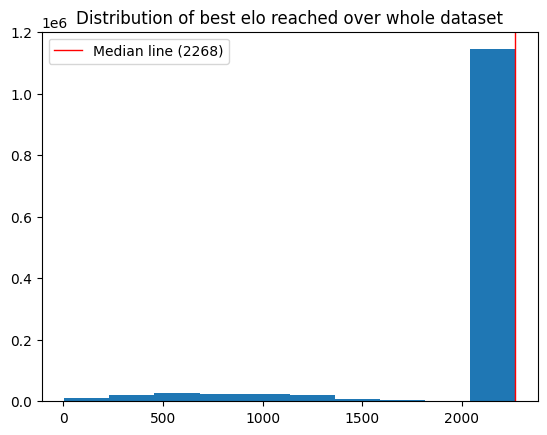

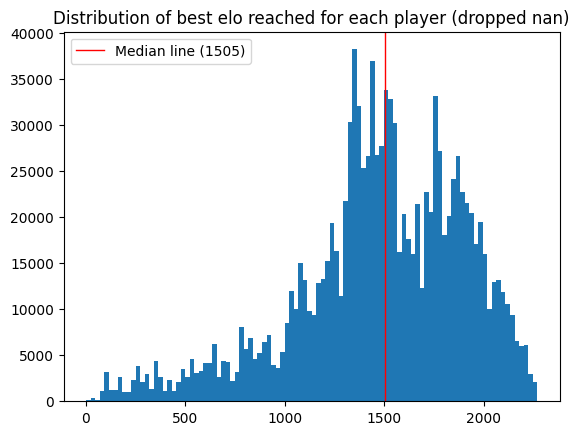

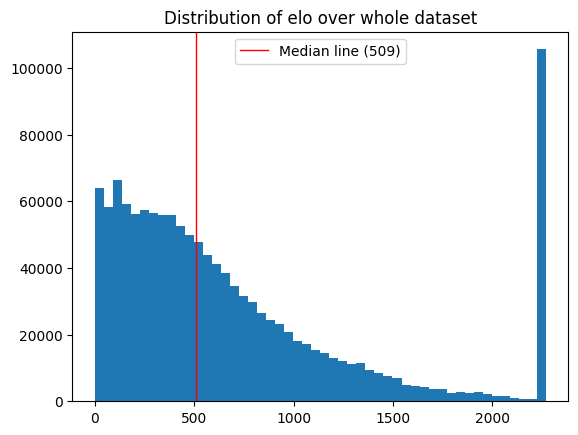

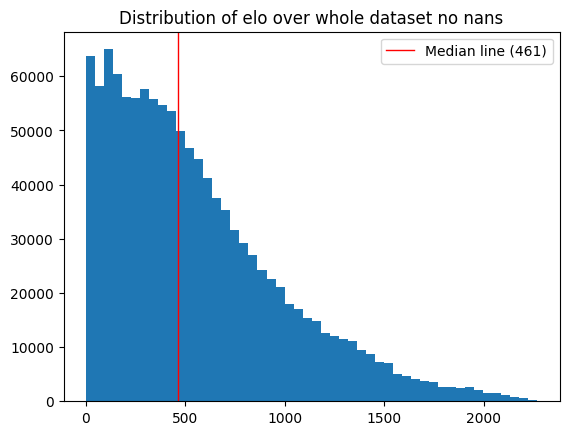

In [ ]:
# histogram of the target var (very skewed because the minimum highest rank is 1500. It could be argued that the max ranks should only be all players who quit early stop at 1500 or lower)
plt.title("Distribution of best rank reached over whole dataset")
plt.hist(full_df['best_rank_reached'],bins=10)
plt.axvline(np.quantile(full_df['best_rank_reached'],0.5),color='red',linewidth=1,label=f'Median line ({int(np.quantile(full_df['best_rank_reached'],0.5))})')
plt.legend()
plt.show()

plt.title("Distribution of best rank reached for each player (dropped nan)")
plt.hist(full_df_2['best_rank_reached'],bins=100)
plt.axvline(np.quantile(full_df_2['best_rank_reached'],0.5),color='red',linewidth=1,label=f'Median line ({int(np.quantile(full_df_2['best_rank_reached'],0.5))})')
plt.legend()
plt.show()

# histogram of the elo
plt.title("Distribution of rank over whole dataset")
plt.hist(full_df['player_rank'],bins=50)
plt.axvline(np.quantile(full_df['player_rank'],0.5),color='red',linewidth=1,label=f'Median line ({int(np.quantile(full_df['player_rank'],0.5))})')
plt.legend()
plt.show()

plt.title("Distribution of rank over whole dataset no nans")
plt.hist(full_df_2['player_rank'],bins=50)
plt.axvline(np.quantile(full_df_2['player_rank'],0.5),color='red',linewidth=1,label=f'Median line ({int(np.quantile(full_df_2['player_rank'],0.5))})')
plt.legend()
plt.show()